In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("../data/students.csv")

X = df[
    [
        "study_hours",
        "attendance",
        "previous_score",
        "assignments",
        "sleep_hours"
    ]
]

y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data loaded successfully!")

Data loaded successfully!


In [2]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,R2 Score
0,Linear Regression,0.446462,0.997645
1,Decision Tree,3.333333,0.862786
2,Random Forest,4.146667,0.722964


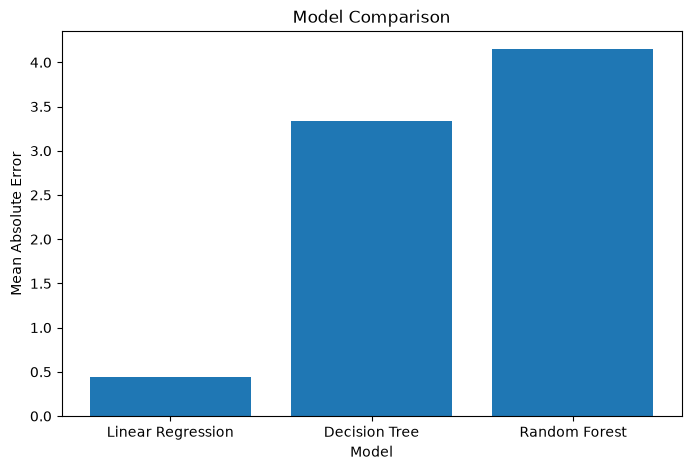

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.title("Model Comparison")

plt.show()